In [70]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mathchi/diabetes-data-set")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mathchi/diabetes-data-set/versions/1


###1. **Limpieza de Datos:**
* **Identificación y eliminación de valores duplicados:** Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
* **Verificación y ajuste de tipos de datos:** Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
* **Corrección de inconsistencias en valores categóricos:** Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
* **Manejo de valores faltantes adecuadamente:** Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

In [71]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "diabetes.csv"))
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [72]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [73]:
# Registros duplicados
print(df.duplicated().sum())

# No se eliminan registros ya que no hay duplicados

0


In [74]:
# Registros nulos
print(df.isnull().sum())

# No se eliminan registros ya que no hay nulos

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [75]:
# Identificación columnas con valores cero que necesitan imputación
columns_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Imputación a valores cero con la mediana para las columnas seleccionadas
for col in columns_to_impute:
    if col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']:
        # Usar la mediana para estas columnas
        median_value = df[df[col] != 0][col].median()
    else:
        median_value = df[df[col] != 0][col].mean()  # Para BMI uso la media

    df[col] = df[col].replace(0, median_value)

# Verificar que no queden valores cero
print(df[columns_to_impute].describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   121.656250      72.386719      29.108073  140.671875   32.457464
std     30.438286      12.096642       8.791221   86.383060    6.875151
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.750000      64.000000      25.000000  121.500000   27.500000
50%    117.000000      72.000000      29.000000  125.000000   32.400000
75%    140.250000      80.000000      32.000000  127.250000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


###2. **Exploración de Datos:**
* **Visualizaciones univariadas y multivariadas:** Crea histogramas, gráficos de barras, diagramas de dispersión y mapas de calor para entender la distribución y las relaciones entre las variables.
* **Estadísticas descriptivas:** Calcula medidas de tendencia central (media, mediana, moda) y de dispersión (rango, desviación estándar) para cada característica del dataset.

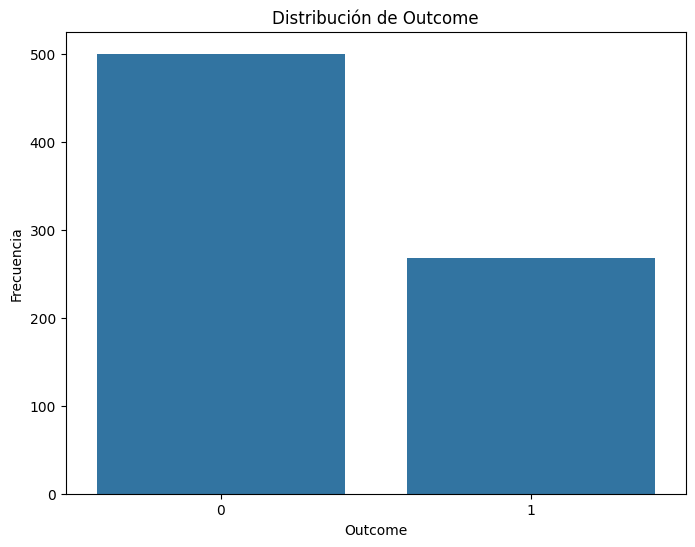

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de Barras para la Variable Outcome
plt.figure(figsize=(8, 6))
sns.countplot(x='Outcome', data=df)
plt.title('Distribución de Outcome')
plt.xlabel('Outcome')
plt.ylabel('Frecuencia')
plt.show()

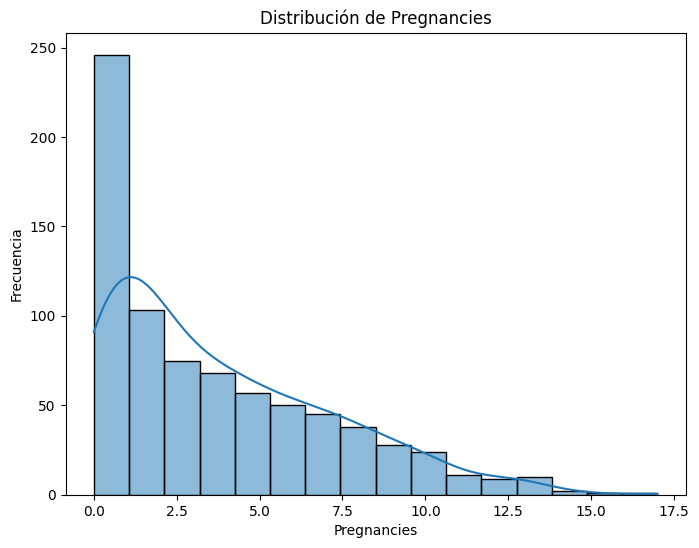

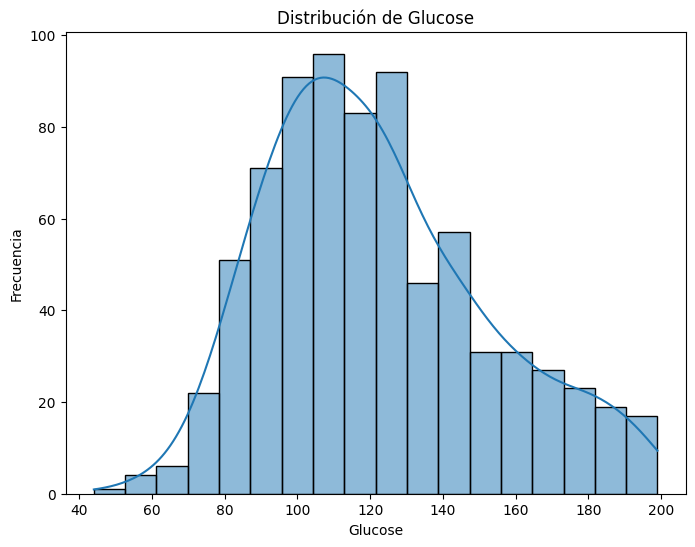

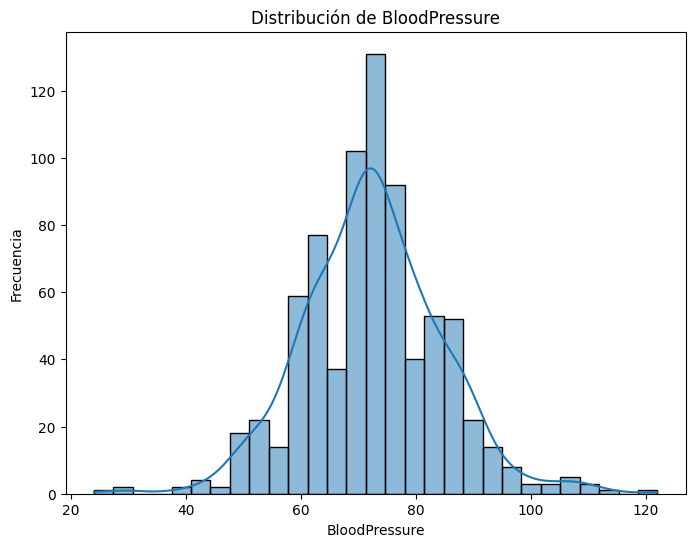

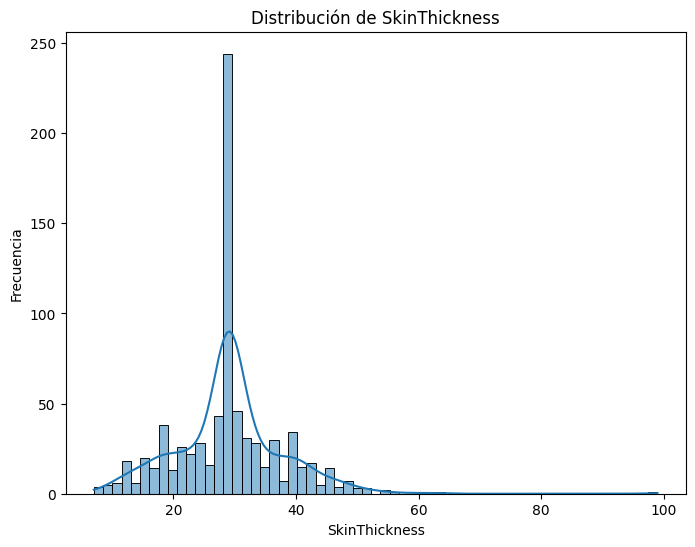

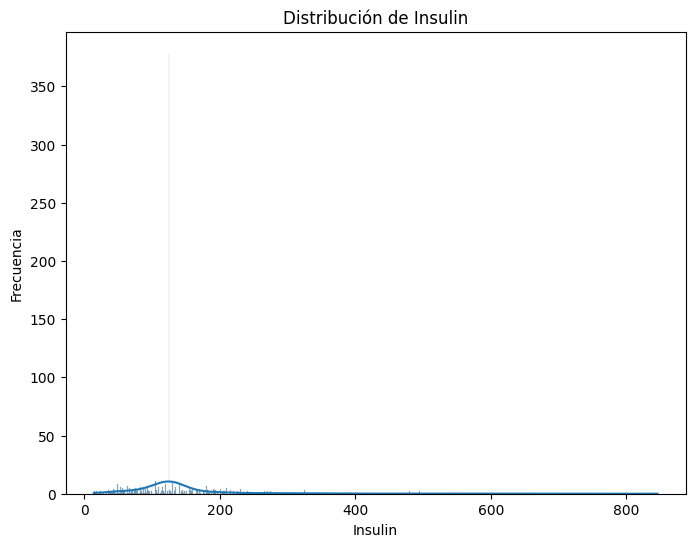

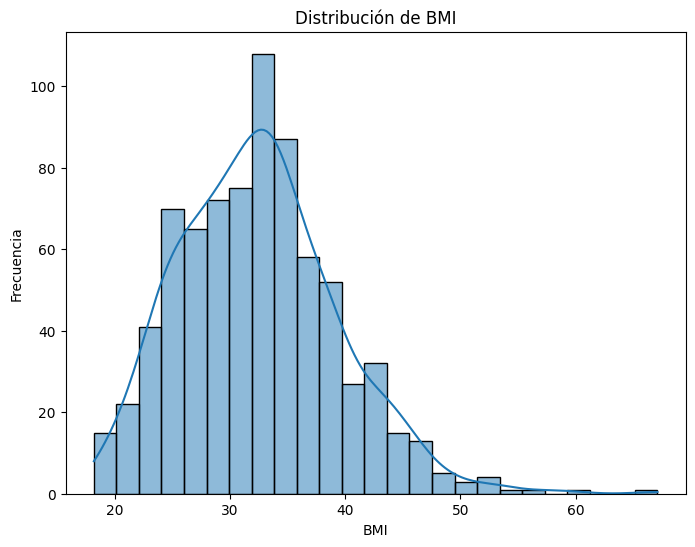

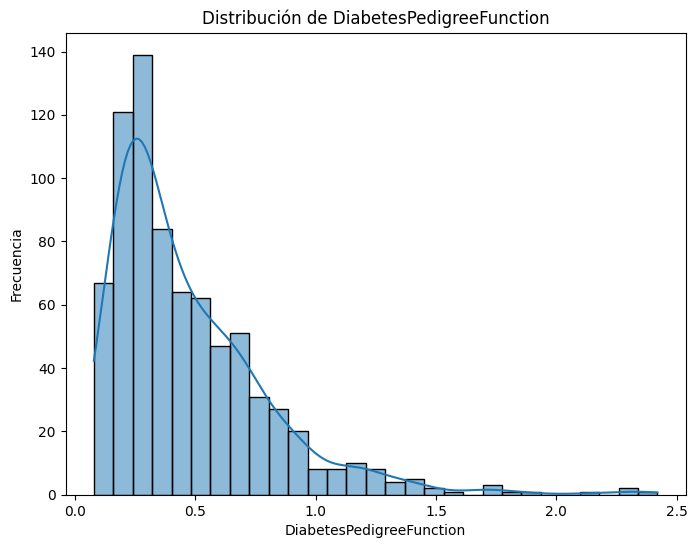

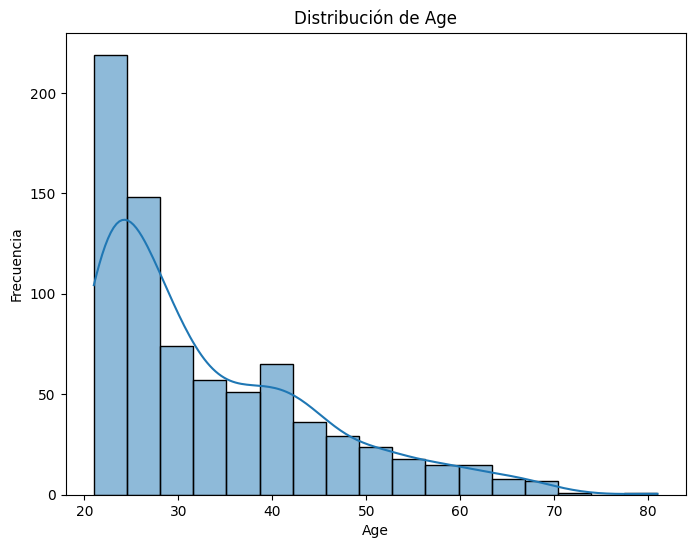

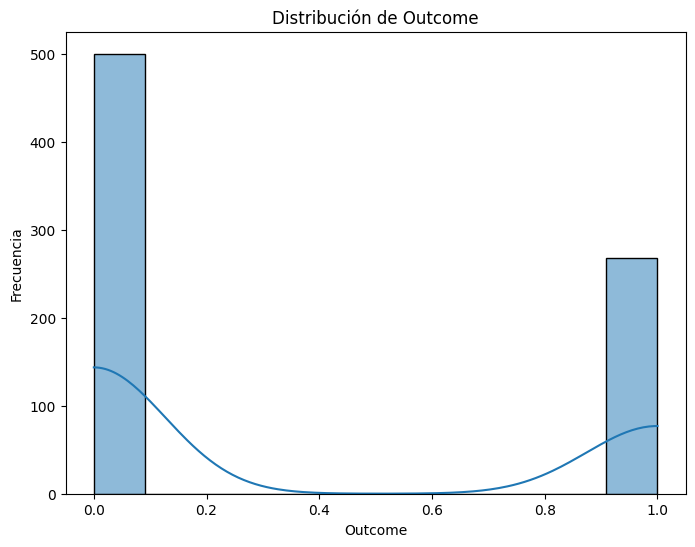

In [77]:
# Distribución de histogramas
for col in df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

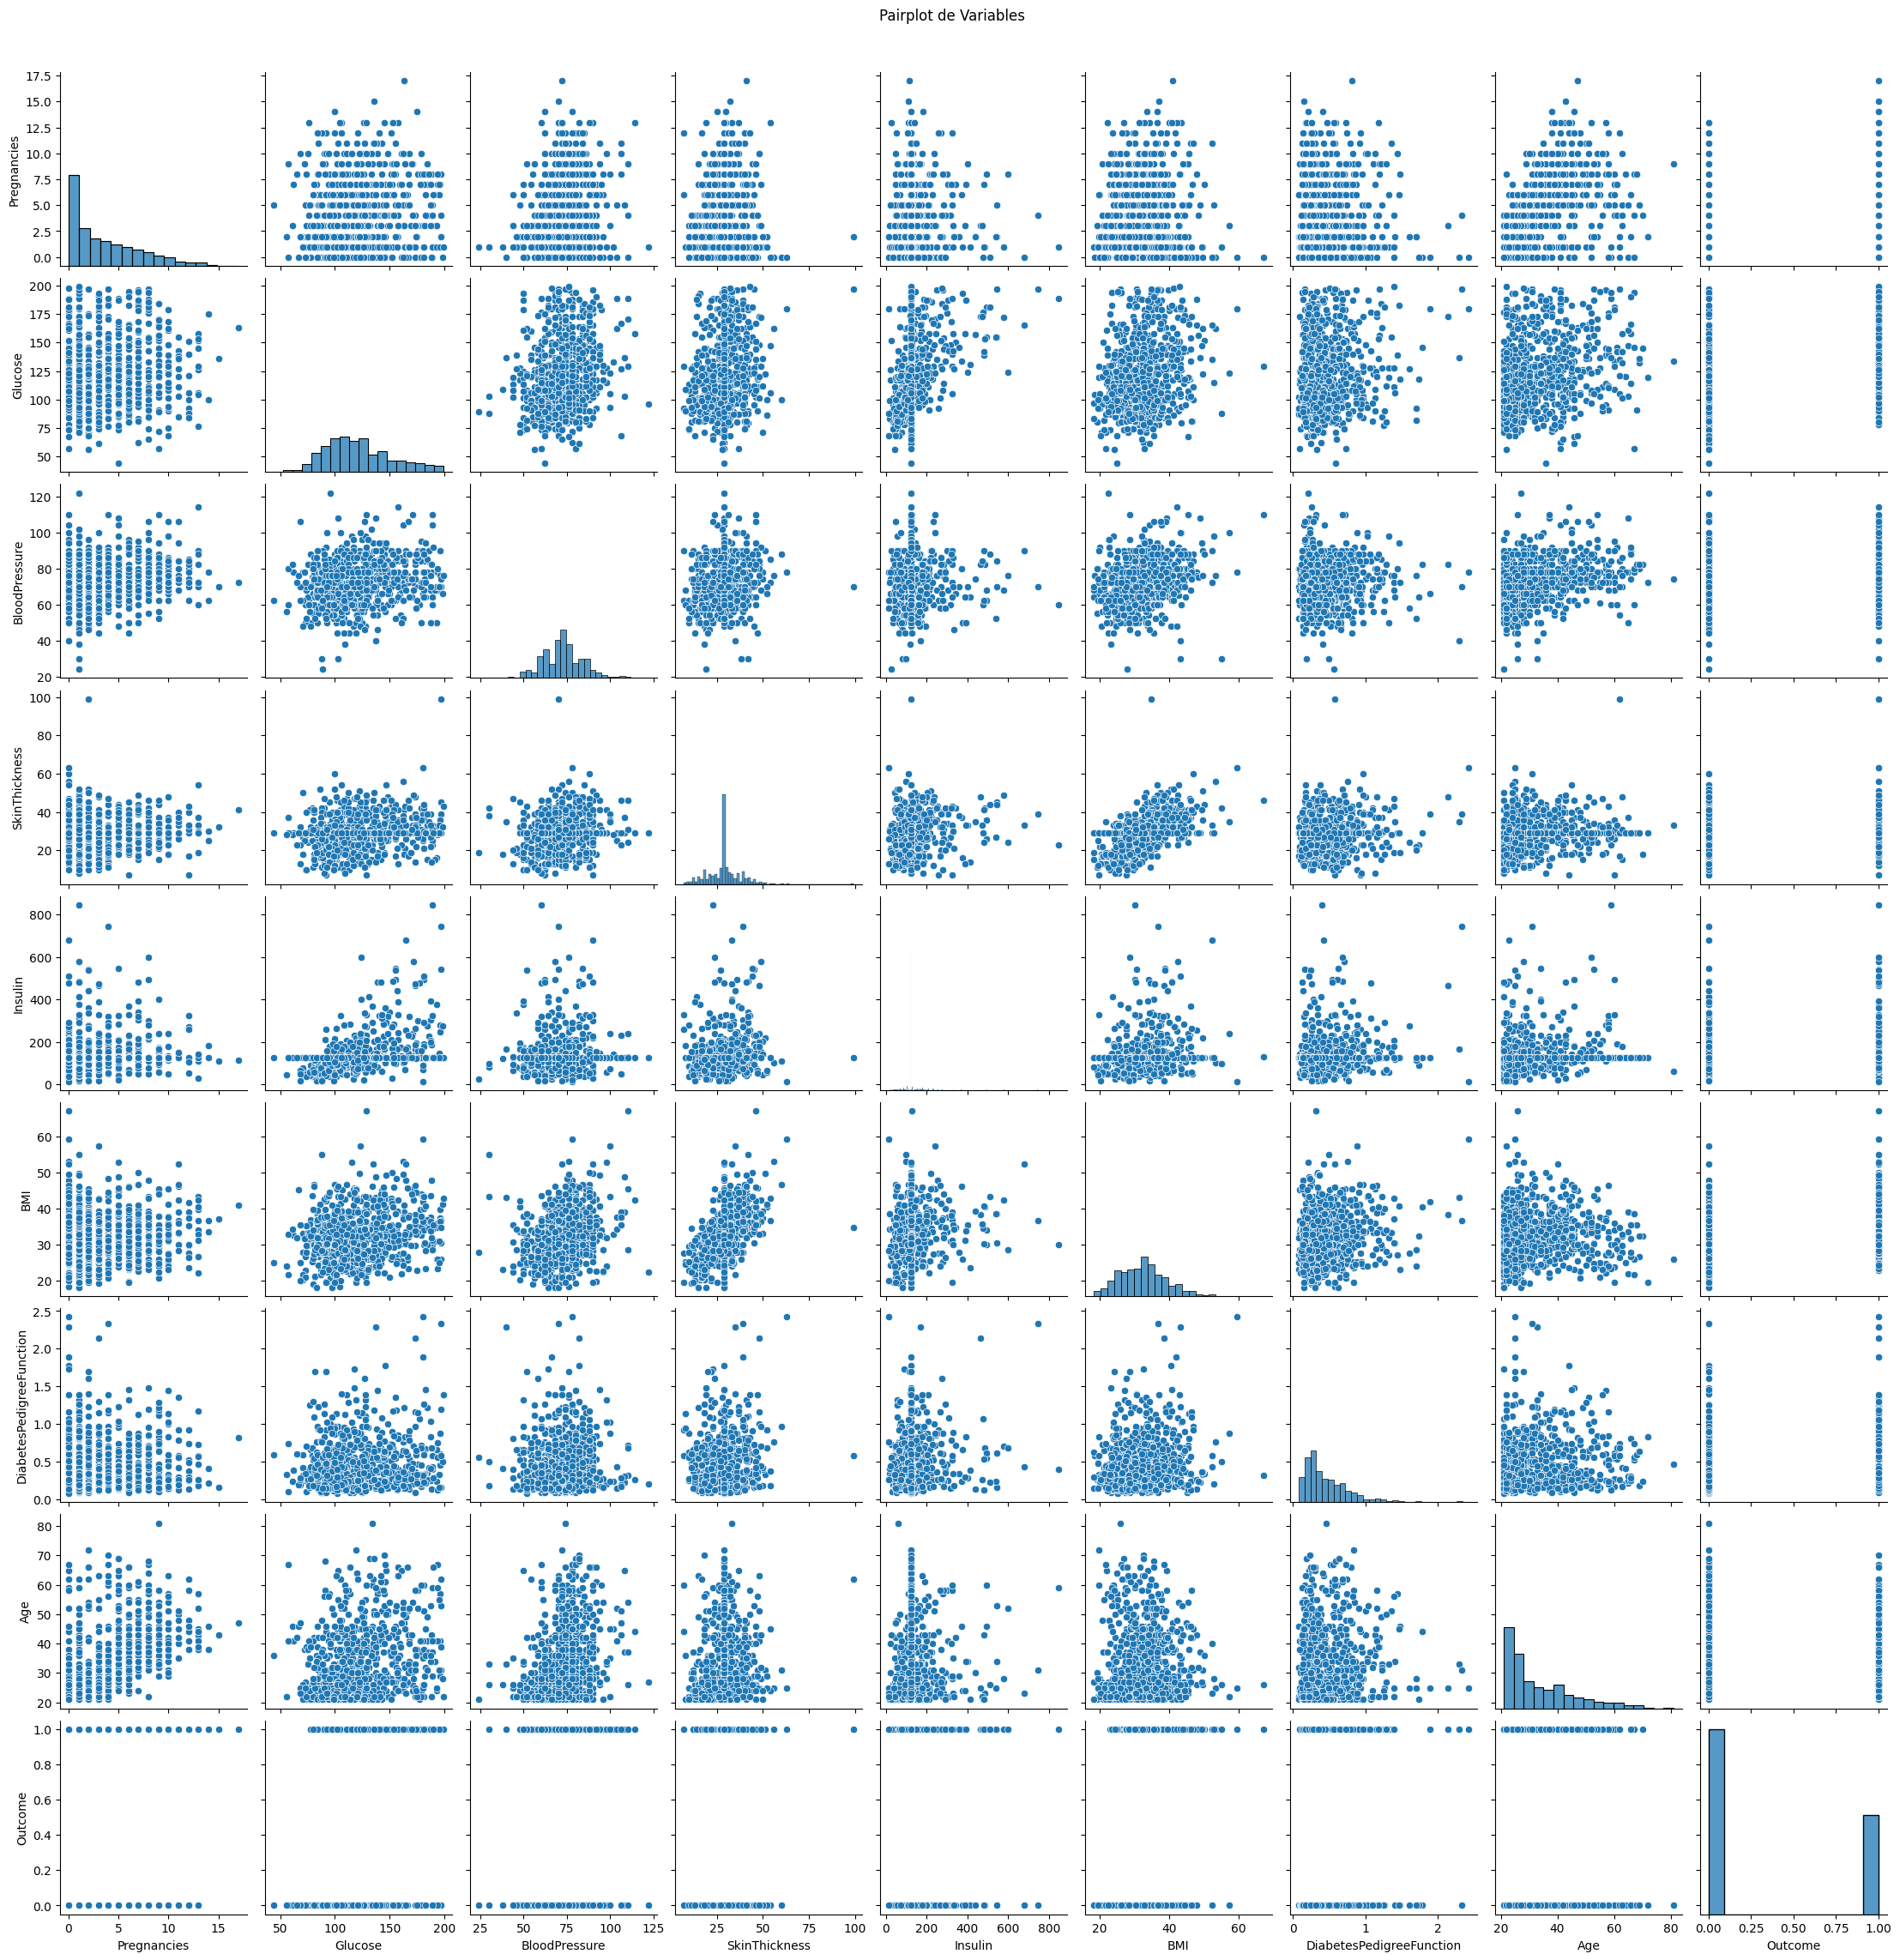

In [78]:
# Visualización multivariada: Pairplot
sns.pairplot(df)
plt.suptitle('Pairplot de Variables', y=1.02)
plt.show()

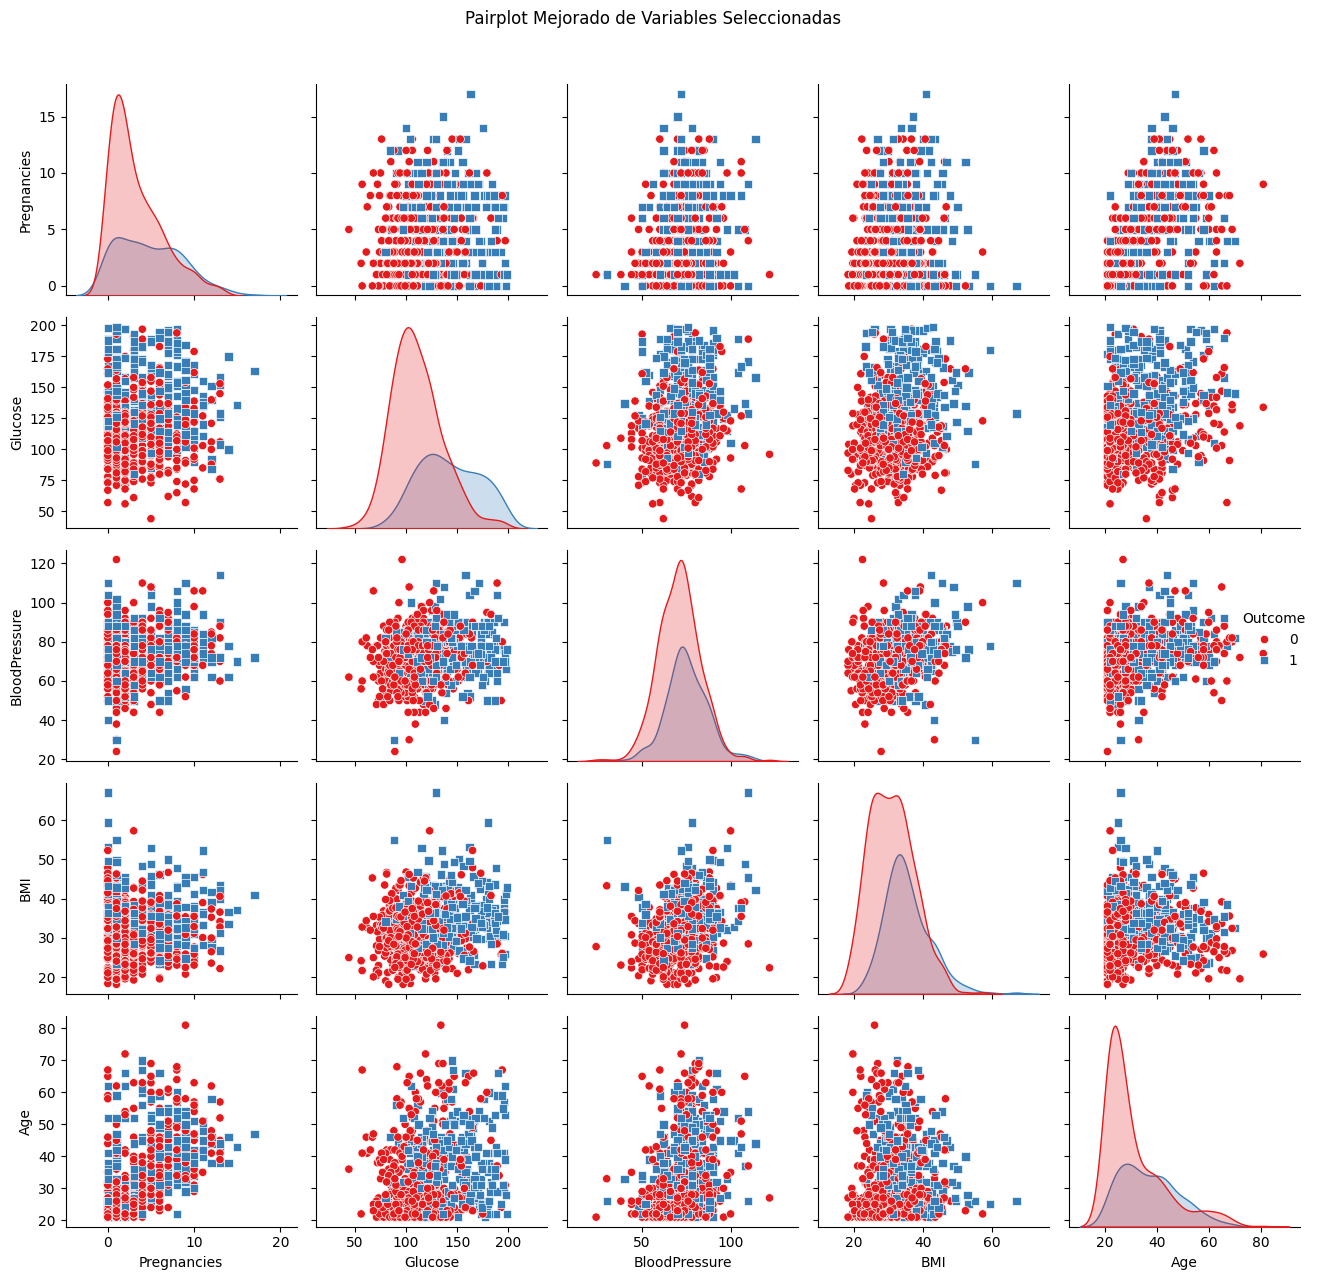

In [79]:
# Segunda visualización más detallada de pairplot: Seleccionar un subconjunto de variables relevantes
variables = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age']

# Pairplot mejorado
sns.pairplot(df, vars=variables, hue='Outcome', diag_kind='kde', palette='Set1', markers=["o", "s"])
plt.suptitle('Pairplot Mejorado de Variables Seleccionadas', y=1.02)

# Ajuste del tamaño de las etiquetas y títulos
plt.tight_layout()
plt.show()

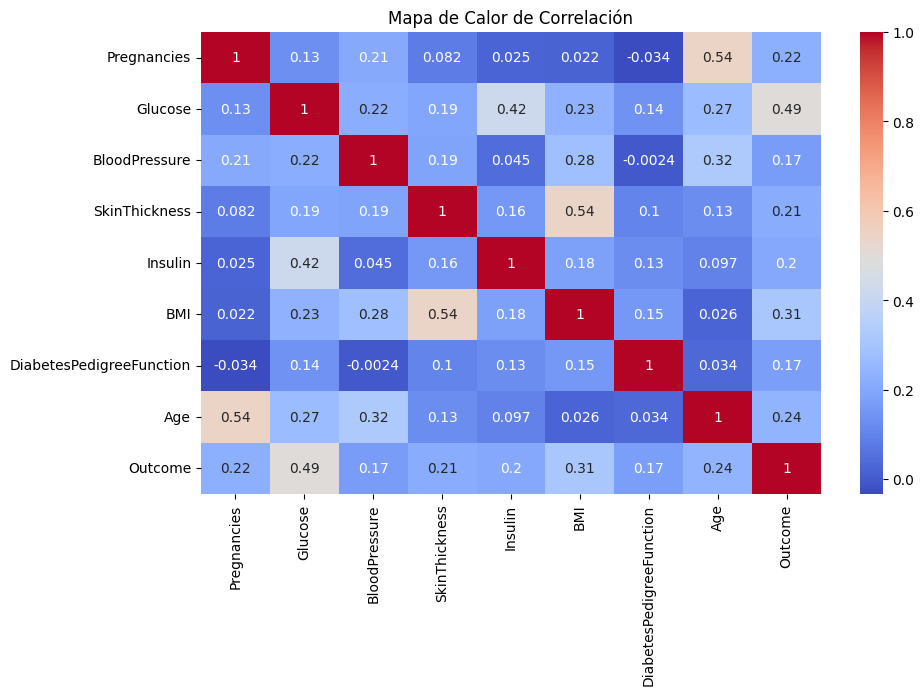

In [80]:
# Visualización multivariada: Heatmap de Correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlación')
plt.show()

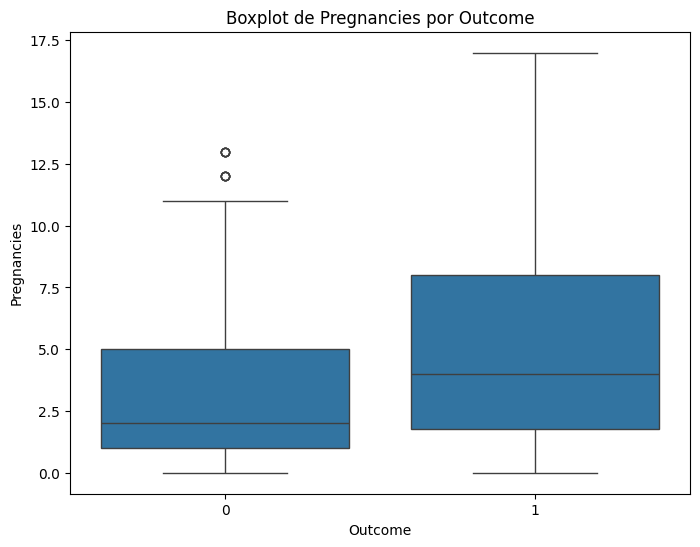

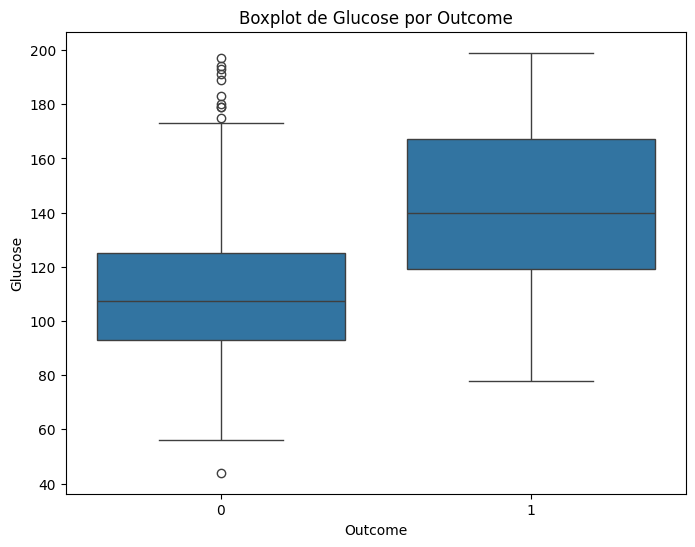

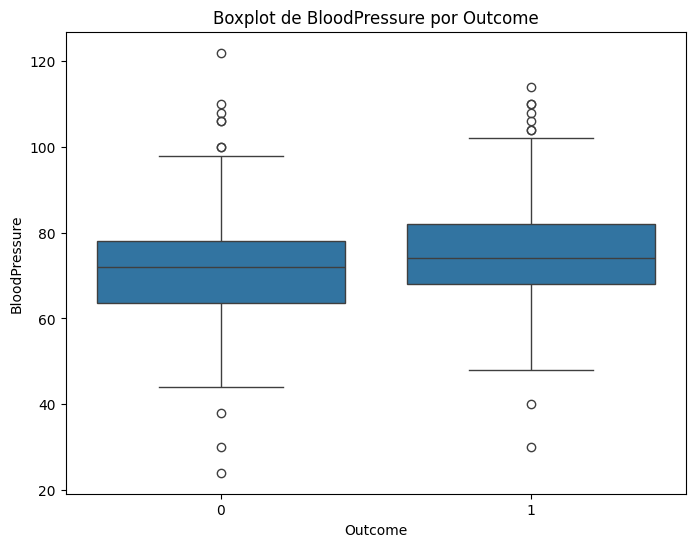

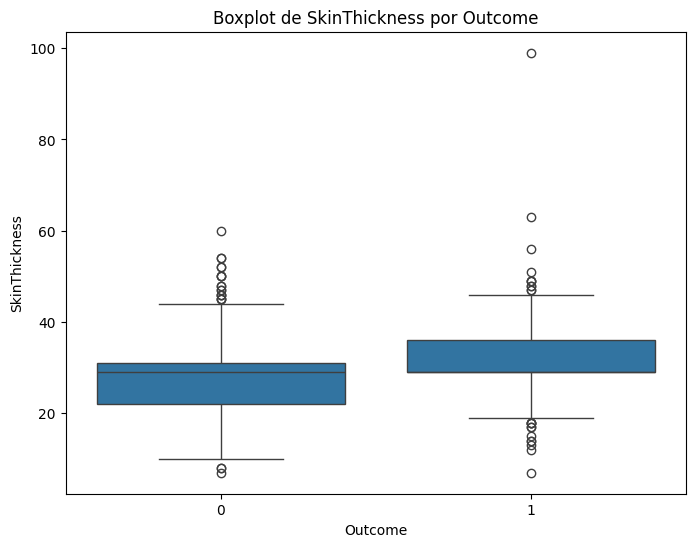

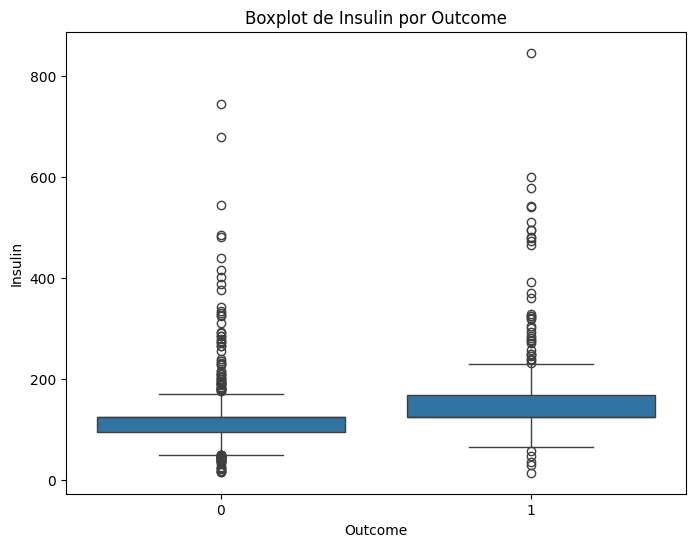

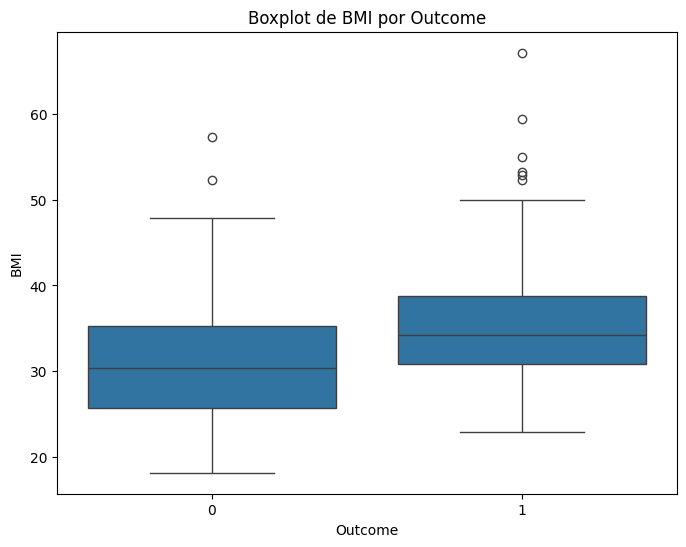

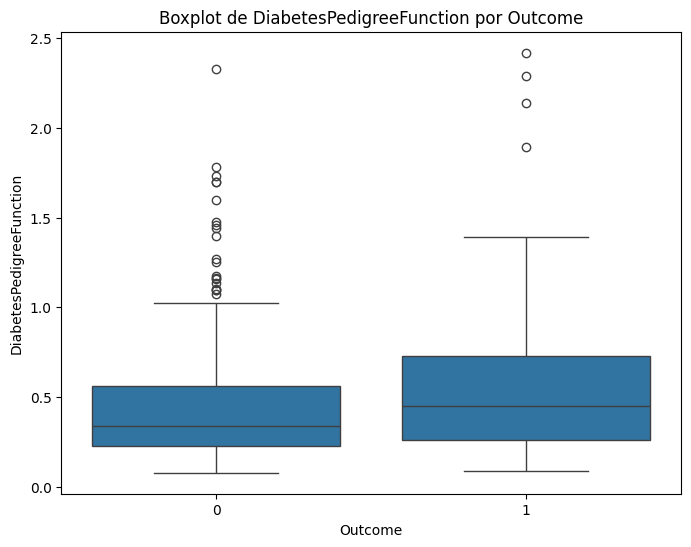

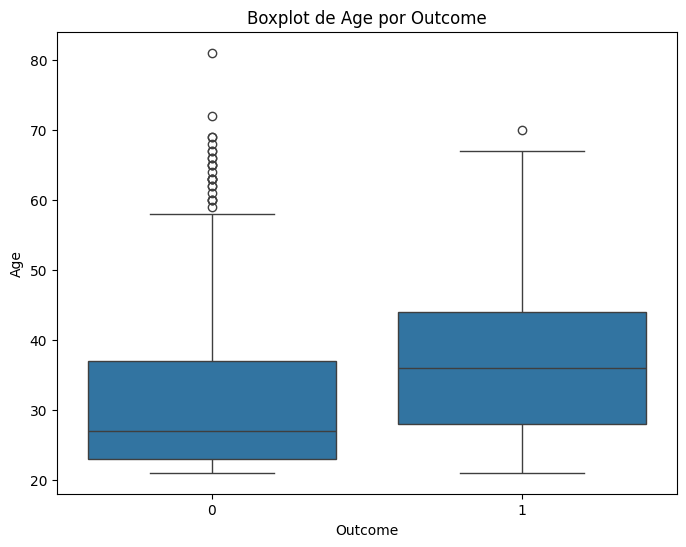

In [81]:
# Boxplots por Variable Objetivo
for col in df.columns[:-1]:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'Boxplot de {col} por Outcome')
    plt.show()

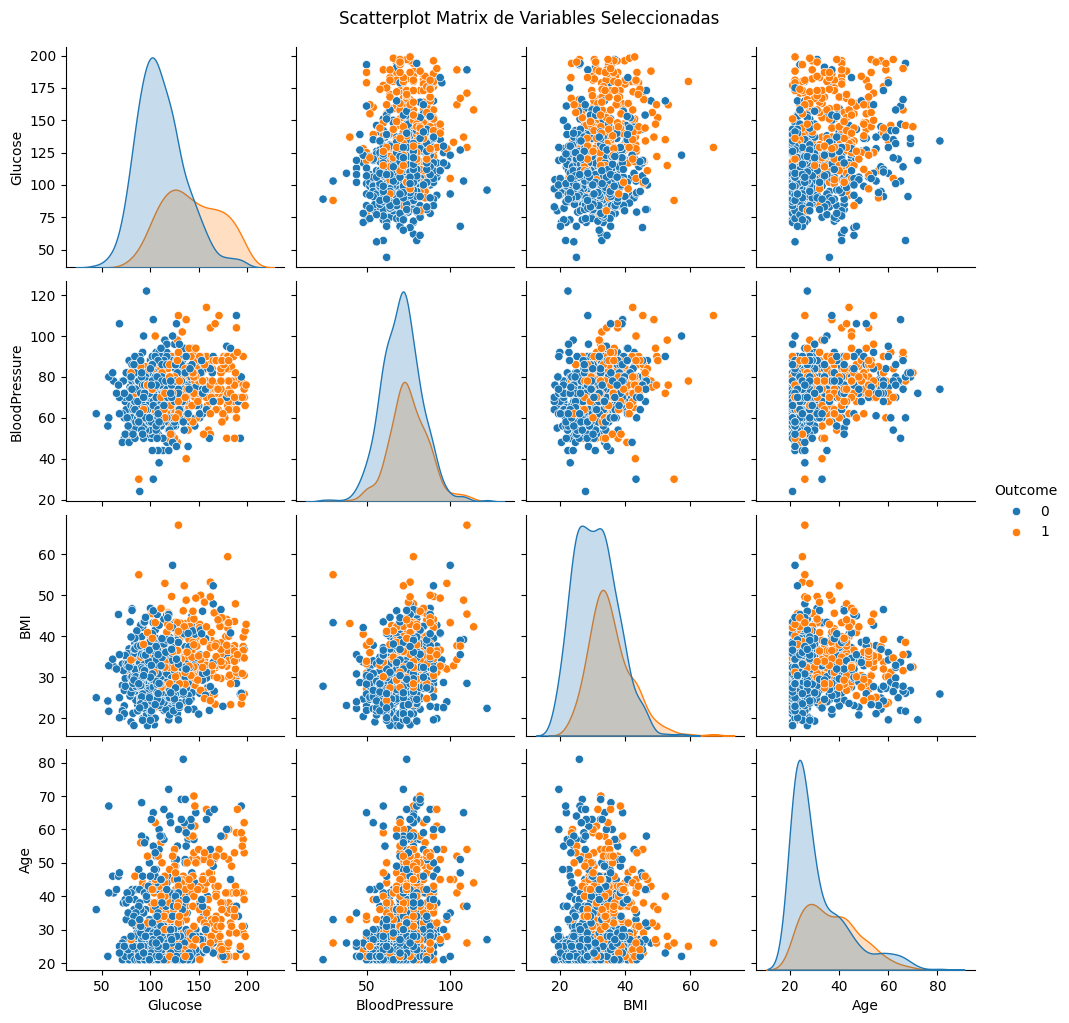

In [82]:
# Scatterplot Matrices
sns.pairplot(df, hue='Outcome', vars=['Glucose', 'BloodPressure', 'BMI', 'Age'])
plt.suptitle('Scatterplot Matrix de Variables Seleccionadas', y=1.02)
plt.show()

In [83]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.875151                  0.331329   11.760232    0.476951  
min     18.200000                  

###3. **Implementación de Modelos:**
* **Modelos de Clasificación:** Implementa modelos de Random Forest y XGBoost.
* Evaluación de Modelos: Evalúa los modelos utilizando métricas como accuracy, precision, recall, F1-score, y ROC-AUC.
* **Comparación de Rendimiento:** Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.

Paso 1: Dividir los Datos

In [99]:
from sklearn.model_selection import train_test_split

# Implementación de Modelos: Dividir los Datos

# División de los datos en características y variable objetivo
X = df.drop(columns='Outcome')
y = df['Outcome']

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}, Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (614, 8), Conjunto de prueba: (154, 8)


Paso 2: Entrenar un Modelo de Random Forest

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Modelo de Random Forest

# Inicialización y entrenamiento del modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba con el modelo Random Forest
y_pred_rf = rf_model.predict(X_test)

# Mostrar los resultados de predicción junto con los datos originales
result_df_rf = X_test.copy()
result_df_rf['Actual'] = y_test
result_df_rf['Prediccion'] = y_pred_rf

print(result_df_rf.head())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32      125  35.7   
624            2      108             64             29      125  30.8   
690            8      107             80             29      125  24.6   
473            7      136             90             29      125  29.9   

     DiabetesPedigreeFunction  Age  Actual  Prediccion  
668                     0.430   43       0           1  
324                     0.148   21       0           0  
624                     0.158   21       0           0  
690                     0.856   34       0           0  
473                     0.210   50       0           1  


In [101]:
# Evaluación del modelo de Random Forest
print("Random Forest - Clasificación de Reporte:\n", classification_report(y_test, y_pred_rf))
print("\nRandom Forest - Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest - Clasificación de Reporte:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154


Random Forest - Matriz de Confusión:
 [[78 21]
 [17 38]]


Paso 3: Entrenar un Modelo de XGBoost

In [102]:
from xgboost import XGBClassifier

# Modelo de XGBoost

# Inicialización y entrenamiento del modelo
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba con el modelo XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Mostrar los resultados de predicción junto con los datos originales
result_df_xgb = X_test.copy()
result_df_xgb['Actual'] = y_test
result_df_xgb['Prediccion'] = y_pred_xgb

print(result_df_xgb.head())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32      125  35.7   
624            2      108             64             29      125  30.8   
690            8      107             80             29      125  24.6   
473            7      136             90             29      125  29.9   

     DiabetesPedigreeFunction  Age  Actual  Prediccion  
668                     0.430   43       0           1  
324                     0.148   21       0           0  
624                     0.158   21       0           0  
690                     0.856   34       0           0  
473                     0.210   50       0           1  


In [103]:
# Evaluación del modelo de XGBoost
print("XGBoost - Clasificación de Reporte:\n", classification_report(y_test, y_pred_xgb))
print("\nXGBoost - Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost - Clasificación de Reporte:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78        99
           1       0.61      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154


XGBoost - Matriz de Confusión:
 [[75 24]
 [18 37]]


Paso 4: Comparar los Modelos

In [104]:
from sklearn.metrics import roc_auc_score

# Comparar el rendimiento de los modelos

# Calcular AUC-ROC
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")
print(f"XGBoost ROC-AUC: {roc_auc_xgb:.4f}")

# Comparar el rendimiento
if roc_auc_rf > roc_auc_xgb:
    print("\n'Random Forest' es el modelo más adecuado para este dataset.")
else:
    print("\n'XGBoost' es el modelo más adecuado para este dataset.")

Random Forest ROC-AUC: 0.7394
XGBoost ROC-AUC: 0.7152

'Random Forest' es el modelo más adecuado para este dataset.


**Optimización de Hiperparámetros**

In [105]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_
print(f"Mejores hiperparámetros: {grid_search.best_params_}")

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist, n_iter=10, cv=5, scoring='roc_auc', random_state=42)
random_search.fit(X_train, y_train)
best_rf_model = random_search.best_estimator_
print(f"Mejores hiperparámetros: {random_search.best_params_}")